In [1]:
# Cell 0 — imports & environment check
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as const
from astropy.coordinates import SkyCoord

# these two are the ones most likely to be missing in a fresh environment
try:
    from astropy.timeseries import LombScargle
    print("astropy OK")
except ImportError:
    print("astropy MISSING  ->  pip install astropy")

try:
    from astroquery.gaia import Gaia
    print("astroquery OK")
except ImportError:
    print("astroquery MISSING  ->  pip install astroquery")

print(f"python {sys.version.split()[0]}, numpy {np.__version__}, "
      f"pandas {pd.__version__}")

pd.set_option('display.max_columns', None)

astropy OK
Please note the archive will not be accessible on 29 July from 11 to 13 CEST, for maintenance purposes. Apologies for the inconveniences.
astroquery OK
python 3.11.7, numpy 2.4.3, pandas 3.0.1


In [2]:
# Cell 1 — SX Phoenicis Period-Luminosity relation: period -> absolute magnitude
#
# Coefficients from Cohen & Sarajedini (2012):
#   M_V = a + b * log10(P_f),  P_f = fundamental-mode period in DAYS.
A_CS, A_ERR = -1.640, 0.110   # intercept (zero-point)
B_CS, B_ERR = -3.389, 0.090   # slope
SIGMA_INTRINSIC = 0.20        # intrinsic scatter of the PL relation (mag).
                              # Star-to-star spread around the mean line from
                              # metallicity/evolutionary differences — see below.

def period_to_absmag(P_f, P_err=0.0, a=A_CS, a_err=A_ERR, b=B_CS, b_err=B_ERR,
                     include_intrinsic=True):
    """Absolute magnitude M_V from fundamental-mode period (days),
    with propagated 1-sigma uncertainty.

    Two distinct uncertainties (they answer different questions):
      - calibration-only: how well we know the MEAN relation (a_err, b_err).
      - +intrinsic scatter: how well we can predict ONE real star, which also
        scatters off the mean line by ~0.2 mag for reasons the relation can't
        capture. For a distance to an individual star, THIS is the honest error
        and it dominates — it's the astrophysical floor of the whole exercise.
    """
    logP = np.log10(P_f)
    M_V  = a + b * logP

    sig_logP = P_err / (P_f * np.log(10))
    var_cal  = a_err**2 + (logP * b_err)**2 + (b * sig_logP)**2   # mean-relation
    var_M    = var_cal + (SIGMA_INTRINSIC**2 if include_intrinsic else 0.0)
    return M_V, np.sqrt(var_M)

# CY Aqr check
P_CYAQR = 0.06103845
M_V, M_err = period_to_absmag(P_CYAQR)
M_V_calonly, M_err_calonly = period_to_absmag(P_CYAQR, include_intrinsic=False)
print(f"log10(P) = {np.log10(P_CYAQR):.4f}")
print(f"M_V = {M_V:.3f} ± {M_err:.3f}   (with intrinsic scatter)")
print(f"M_V = {M_V_calonly:.3f} ± {M_err_calonly:.3f}   (calibration only)")

log10(P) = -1.2144
M_V = 2.476 ± 0.253   (with intrinsic scatter)
M_V = 2.476 ± 0.155   (calibration only)


In [3]:
# Cell 2 — Distance from the distance modulus
#   m - M = 5*log10(d) - 5 + A_V   ->   d = 10**((m - M - A_V + 5)/5)
# m   = intensity-mean apparent V (from the AAVSO/instrumental pipeline)
# M   = absolute magnitude from Cell 1
# A_V = interstellar extinction along the sightline (small but not zero)

def distance_from_modulus(m, M, A_V=0.0, m_err=0.0, M_err=0.0, A_err=0.0):
    """Distance in parsecs from apparent & absolute magnitude, with extinction
    correction and propagated 1-sigma uncertainty."""
    mu0 = m - M - A_V                      # extinction-corrected distance modulus
    d   = 10**((mu0 + 5) / 5)

    # The corrected modulus is a simple sum, so its variance is the sum of input
    # variances. Distance is exponential in the modulus: dd/dmu = d*ln(10)/5.
    sig_mu = np.sqrt(m_err**2 + M_err**2 + A_err**2)
    d_err  = d * (np.log(10) / 5) * sig_mu
    return d, d_err

# Dry-run check with the validated single-night AAVSO values for CY Aqr:
V_mean, V_err = 10.929, 0.02      # apparent intensity-mean V and its uncertainty
A_V,   A_err  = 0.10,  0.05       # small extinction, clean high-latitude sightline

d, d_err = distance_from_modulus(V_mean, M_V, A_V, V_err, M_err, A_err)
print(f"distance modulus (corrected) = {V_mean - M_V - A_V:.3f}")
print(f"d = {d:.0f} ± {d_err:.0f} pc")
print(f"fractional uncertainty = {100*d_err/d:.0f}%")

distance modulus (corrected) = 8.353
d = 468 ± 56 pc
fractional uncertainty = 12%


In [4]:
# Cell 3 — Period recovery via Lomb-Scargle (+ periodogram plot)

def find_period(times, mags, p_min=0.02, p_max=0.15, samples_per_peak=10):
    """Recover the dominant pulsation period via Lomb-Scargle.
    Independent of brightness calibration — only the timing/shape of the
    variation matters, so it runs on raw instrumental or AAVSO magnitudes."""
    times = np.asarray(times, float)
    mags  = np.asarray(mags, float)

    # DECISION: 0.02-0.15 d window brackets the SX Phe regime; narrow = fewer
    # spurious peaks. REVISIT (widen) for other variable classes.
    f_min, f_max = 1.0 / p_max, 1.0 / p_min

    # DECISION: samples_per_peak=10 oversamples the frequency grid so a narrow
    # peak isn't stepped over. Standard safe value.
    ls = LombScargle(times, mags)
    freq, power = ls.autopower(minimum_frequency=f_min,
                               maximum_frequency=f_max,
                               samples_per_peak=samples_per_peak)

    # DECISION: take the single highest peak (argmax). Naive — can lock onto an
    # alias or the half-period harmonic. The periodogram plot + literature marker
    # guard against that here. REVISIT for blind measurements (add alias checks).
    best_freq = freq[np.argmax(power)]
    best_period = 1.0 / best_freq

    diag = {"freq": freq, "power": power, "period_grid": 1.0 / freq,
            "best_period": best_period, "best_power": power.max()}
    return best_period, diag


def plot_periodogram(diag, known_period=None,
                     title="CY Aqr — Lomb-Scargle periodogram"):
    """Power vs period, marking the recovered peak and optional reference."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(diag["period_grid"], diag["power"], lw=0.8, color="steelblue")
    ax.axvline(diag["best_period"], color="crimson",
               label=f"recovered = {diag['best_period']:.6f} d")
    if known_period:
        ax.axvline(known_period, color="green", ls="--",
                   label=f"literature = {known_period:.6f} d")
    ax.set(xlabel="period (days)", ylabel="LS power", title=title)
    ax.legend(); plt.tight_layout(); plt.show()

print("find_period + plot_periodogram defined")

find_period + plot_periodogram defined


In [5]:
# Cell 4 — Intensity-mean apparent magnitude via phase folding (+ plot)

def fold_and_mean(times, mags, period, t0=None, n_bins=20):
    """Intensity-mean apparent magnitude over one folded pulsation cycle.

    Folds on `period`, bins uniformly in phase, and flux-averages so every
    phase bin gets EQUAL weight regardless of sample count. Corrects the two
    biases in a straight mean: averaging in flux (not log) space, and weighting
    by phase (not raw sample count, since the star lingers at minimum)."""
    times = np.asarray(times, float)
    mags  = np.asarray(mags, float)

    # DECISION: t0 defaults to first timestamp. Phase-zero is arbitrary for the
    # MEAN, so harmless. REVISIT only to pin phase-zero to maximum for plotting.
    if t0 is None:
        t0 = times.min()

    phase = ((times - t0) / period) % 1.0
    flux  = 10**(-0.4 * mags)

    # DECISION: n_bins=20 resolves the sawtooth yet stays filled on a dense night.
    # REVISIT per your point count (aim >=5 points/bin).
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx   = np.clip(np.digitize(phase, edges) - 1, 0, n_bins - 1)

    bin_flux = np.full(n_bins, np.nan)
    bin_n    = np.zeros(n_bins, int)
    for b in range(n_bins):
        sel = idx == b
        bin_n[b] = sel.sum()
        if bin_n[b] > 0:
            bin_flux[b] = flux[sel].mean()

    # DECISION: empty bins are SKIPPED (not interpolated) — the math must not
    # invent data for an unobserved phase. We skip honestly and REPORT coverage
    # so the bias is visible. REVISIT if you later choose to model gaps.
    occupied  = bin_n > 0
    mean_flux = np.nanmean(bin_flux[occupied])
    V_mean    = -2.5 * np.log10(mean_flux)

    diag = {"phase": phase, "mags": mags,
            "bin_centers": 0.5 * (edges[:-1] + edges[1:]),
            "bin_mag": -2.5 * np.log10(bin_flux),
            "bin_n": bin_n, "occupied": occupied,
            "n_empty": int((~occupied).sum()), "coverage": occupied.mean(),
            "V_mean": V_mean, "V_naive": mags.mean(), "period": period}
    return V_mean, diag


def plot_folded(diag, title="CY Aqr — folded light curve"):
    """Folded light curve with binned means; empty (gap) bins highlighted."""
    bc, bm = diag["bin_centers"], diag["bin_mag"]
    fig, ax = plt.subplots(figsize=(8, 5))
    for shift in (0, 1):                          # two cycles for visual continuity
        ax.scatter(diag["phase"] + shift, diag["mags"], s=8, alpha=0.4,
                   color="gray", label="data" if shift == 0 else None)
        ax.plot(bc + shift, bm, "o-", color="crimson",
                label="phase-binned mean" if shift == 0 else None)
    ax.axhline(diag["V_mean"], ls="--", color="navy",
               label=f"intensity mean = {diag['V_mean']:.3f}")
    w = 1.0 / len(bc)
    for c, occ in zip(bc, diag["occupied"]):      # highlight coverage gaps
        if not occ:
            for shift in (0, 1):
                ax.axvspan(c + shift - w/2, c + shift + w/2,
                           color="orange", alpha=0.2)
    ax.invert_yaxis()
    ax.set(xlabel="phase", ylabel="V (mag)", title=title)
    ax.legend(loc="best")
    print(f"phase coverage: {100*diag['coverage']:.0f}%  "
          f"({diag['n_empty']} empty bins of {len(bc)})")
    print(f"intensity mean V = {diag['V_mean']:.3f}   "
          f"(naive mag mean = {diag['V_naive']:.3f}, "
          f"bias = {diag['V_naive'] - diag['V_mean']:+.3f})")
    plt.tight_layout(); plt.show()

print("fold_and_mean + plot_folded defined")

fold_and_mean + plot_folded defined


In [6]:
# Cell 5 — Load an AAVSO WebObs CSV into clean (times, mags) arrays

def load_aavso(path, band="V", transformed_only=False,
               valid_flags=("V", "Z"), densest_night=True):
    """Load an AAVSO WebObs CSV into clean (times, mags) arrays for the pipeline.
    Expected columns: JD, HJD, Magnitude, Uncertainty, Band, Transformed,
    Validation Flag. Returns (times, mags, meta)."""
    # low_memory=False: read the whole file at once so pandas infers one dtype
    # per column instead of chunk-by-chunk. Silences the DtypeWarning caused by
    # the free-text Comment Code / notes columns having mixed content.
    df = pd.read_csv(path, low_memory=False)
    df.columns = [c.strip() for c in df.columns]     # WebObs pads header names

    sel = df["Band"] == band                          # exact-match Johnson V only
    d = df[sel].copy()
    d["mag"] = pd.to_numeric(d["Magnitude"], errors="coerce")

    tcol = "HJD" if ("HJD" in d.columns and d["HJD"].notna().any()) else "JD"
    d["t"] = pd.to_numeric(d[tcol], errors="coerce")

    if transformed_only and "Transformed" in d.columns:
        d = d[d["Transformed"] == "Yes"]
    if valid_flags and "Validation Flag" in d.columns:
        d = d[d["Validation Flag"].isin(valid_flags)]

    d = d.dropna(subset=["mag", "t"]).sort_values("t")

    meta = {"n_total": int(sel.sum()), "n_clean": len(d), "tcol": tcol,
            "jd_range": (float(d["t"].min()), float(d["t"].max()))}

    if densest_night:
        d["night"] = np.floor(d["t"] - 0.5).astype(int)
        best = d.groupby("night").size().sort_values(ascending=False).index[0]
        d = d[d["night"] == best]
        span_h = (d["t"].max() - d["t"].min()) * 24
        meta.update(night=int(best), n_night=len(d), span_hours=span_h)

    times, mags = d["t"].values, d["mag"].values
    print(f"loaded {meta['n_clean']} clean {band} points "
          f"(from {meta['n_total']} in band)")
    if densest_night:
        print(f"densest night JD {meta['night']}: {meta['n_night']} pts "
              f"over {meta['span_hours']:.1f} h")
    return times, mags, meta

print("load_aavso defined (DtypeWarning patched)")

load_aavso defined (DtypeWarning patched)


In [7]:
# Cell 6 — Reusable pipeline: run any AAVSO/instrumental CSV through the full
#   period -> fold -> mean -> distance chain. Charts render first, then one
#   consolidated summary block. Works for your V download, the PEX TG night,
#   or your own future data — just change the path, band, and is_standard_V flag.

def run_pipeline(csv_path, band="V", densest_night=True, fold_period=P_CYAQR,
                 A_V=0.10, A_err=0.05, m_err=0.02, is_standard_V=True,
                 label=None):
    """
    Full period -> fold -> mean -> distance pipeline on one dataset.

    band          : which AAVSO band to load ("V", "TG", etc.)
    densest_night : True = single densest night; False = fold all nights
    fold_period   : period to fold on for the mean (default: literature P_CYAQR)
    is_standard_V : True if these mags are on the standard V system. If False
                    (e.g. untransformed TG), the distance is still computed but
                    flagged as uncalibrated in the summary — it carries a colour
                    offset and is shown for comparison only (Notes #5, #8).
    label         : optional name for printouts (defaults to the filename)

    Renders the periodogram and folded-curve charts, THEN prints one
    consolidated summary block below both. Returns a result dict.
    """
    label = label or csv_path

    # 1) load (quiet — summarized at the end)
    times, mags, meta = load_aavso(csv_path, band=band, densest_night=densest_night)

    # 2) recover period + periodogram chart (band-agnostic — timing only)
    period_rec, pdiag = find_period(times, mags)
    plot_periodogram(pdiag, known_period=P_CYAQR)

    # 3) fold + intensity mean + folded-curve chart
    mean_mag, fdiag = fold_and_mean(times, mags, fold_period)
    plot_folded(fdiag, title=f"{label} — folded {band} light curve")

    # 4) distance — always compute, but flag when the band isn't standard V
    pct_off  = 100 * abs(period_rec - P_CYAQR) / P_CYAQR
    n_cycles = (times.max() - times.min()) / P_CYAQR
    d, d_err = distance_from_modulus(mean_mag, M_V, A_V=A_V,
                                     m_err=m_err, M_err=M_err, A_err=A_err)

    # --- consolidated summary, printed AFTER both charts ---
    tag = "" if is_standard_V else "   [UNCALIBRATED — band not standard V]"
    lines = [
        f"===== {label}  (band={band}, "
        f"{'densest night' if densest_night else 'all nights'}) =====",
        f"  points          : {meta['n_clean']}"
        + (f"   (densest night: {meta.get('n_night','?')} pts)" if densest_night else ""),
        f"  baseline        : {n_cycles:.1f} cycles",
        f"  period recovered: {period_rec*1440:.3f} min  ({pct_off:.2f}% off literature)",
        f"  phase coverage  : {100*fdiag['coverage']:.0f}%  "
        f"({fdiag['n_empty']} empty bins)",
        f"  intensity mean  : {mean_mag:.3f} {band}",
        f"  distance        : {d:.0f} ± {d_err:.0f} pc  ({100*d_err/d:.0f}%){tag}",
        f"  Gaia answer key : 413 [409, 416] pc",
    ]
    if not is_standard_V:
        lines.append(f"  note: {band} is not on the standard V system, so this "
                     f"distance carries a colour offset — shown for comparison only.")

    print("\n" + "\n".join(lines) + "\n")

    return {"label": label, "band": band, "meta": meta,
            "period_recovered": period_rec, "pct_off": pct_off, "n_cycles": n_cycles,
            "mean_mag": mean_mag, "fdiag": fdiag, "is_standard_V": is_standard_V,
            "distance_pc": d, "distance_err_pc": d_err}

loaded 9427 clean V points (from 29008 in band)


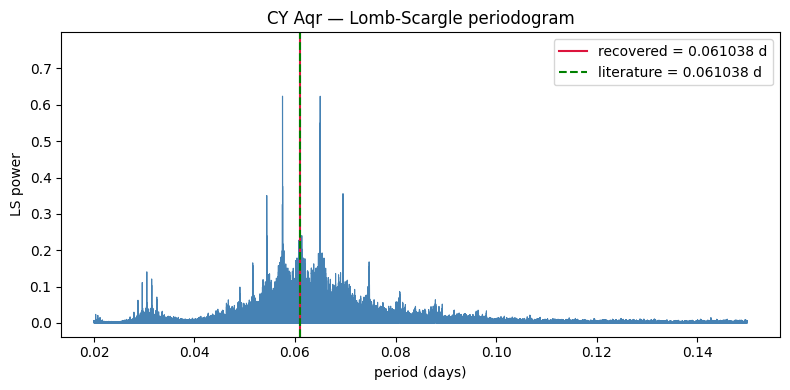

phase coverage: 100%  (0 empty bins of 20)
intensity mean V = 10.893   (naive mag mean = 10.922, bias = +0.030)


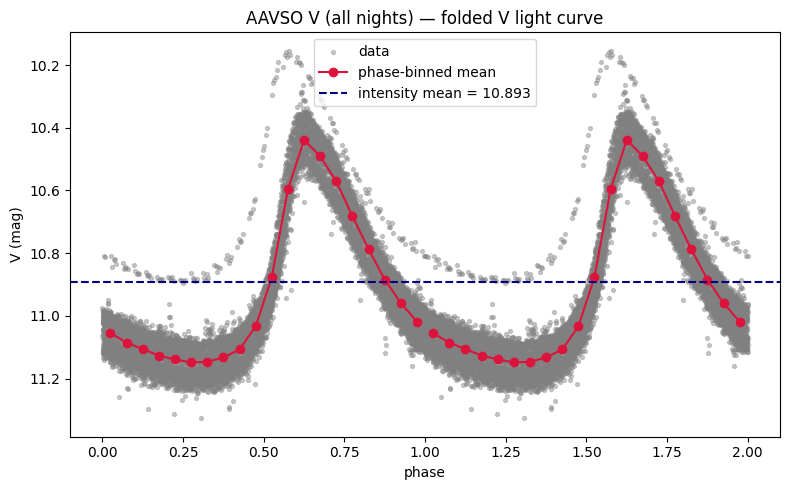


===== AAVSO V (all nights)  (band=V, all nights) =====
  points          : 9427
  baseline        : 67155.4 cycles
  period recovered: 87.895 min  (0.00% off literature)
  phase coverage  : 100%  (0 empty bins)
  intensity mean  : 10.893 V
  distance        : 461 ± 55 pc  (12%)
  Gaia answer key : 413 [409, 416] pc



In [8]:
# --- run the validated V dataset (the scientific result) ---
res_V = run_pipeline("cyaqr_aavso.csv", band="V", densest_night=False,
                     is_standard_V=True, label="AAVSO V (all nights)")

loaded 180 clean TG points (from 180 in band)
densest night JD 2460886: 180 pts over 3.0 h


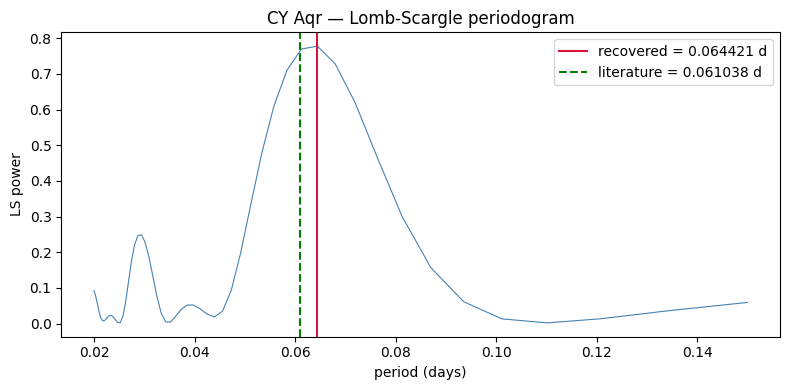

phase coverage: 100%  (0 empty bins of 20)
intensity mean V = 10.875   (naive mag mean = 10.909, bias = +0.034)


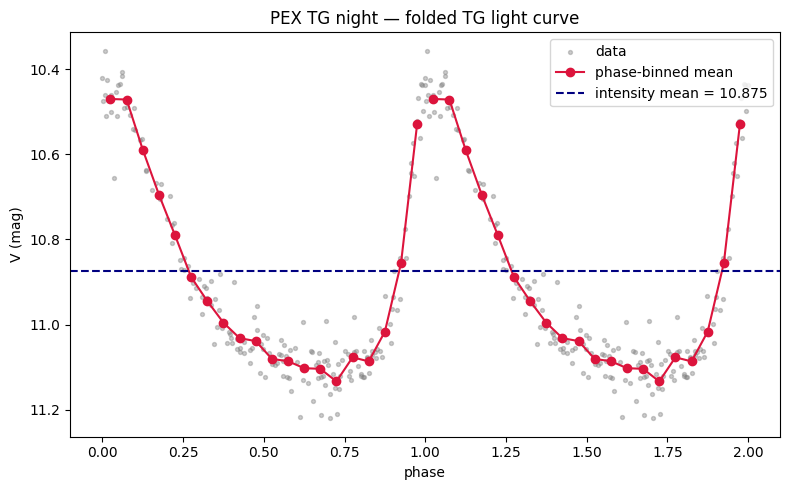


===== PEX TG night  (band=TG, densest night) =====
  points          : 180   (densest night: 180 pts)
  baseline        : 2.0 cycles
  period recovered: 92.766 min  (5.54% off literature)
  phase coverage  : 100%  (0 empty bins)
  intensity mean  : 10.875 TG
  distance        : 457 ± 54 pc  (12%)   [UNCALIBRATED — band not standard V]
  Gaia answer key : 413 [409, 416] pc
  note: TG is not on the standard V system, so this distance carries a colour offset — shown for comparison only.



In [9]:
# Cell 6-TG — the PEX untransformed TG night, same pipeline
res_TG = run_pipeline("cyaqr_aavso_tg.csv", band="TG", densest_night=True,
                      is_standard_V=False, label="PEX TG night")

In [10]:
# Cell 7 — Gaia DR3 crosscheck: the independent "answer key"
#   Resolves CY Aqr's position via SIMBAD at runtime (no hardcoded coords),
#   then pulls raw parallax + Bailer-Jones geometric distance from Gaia DR3.

from astroquery.gaia import Gaia
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord
import astropy.units as u

def resolve_coords(name):
    """Look up an object's ICRS coordinates by name via SIMBAD."""
    res = Simbad.query_object(name)
    if res is None or len(res) == 0:
        raise RuntimeError(f"SIMBAD could not resolve '{name}'")
    # SIMBAD returns RA/Dec; column names vary by astroquery version
    ra_col  = "ra"  if "ra"  in res.colnames else "RA"
    dec_col = "dec" if "dec" in res.colnames else "DEC"
    val_ra, val_dec = res[ra_col][0], res[dec_col][0]
    # newer astroquery returns degrees (float); older returns sexagesimal strings
    try:
        c = SkyCoord(float(val_ra)*u.deg, float(val_dec)*u.deg, frame="icrs")
    except (ValueError, TypeError):
        c = SkyCoord(str(val_ra), str(val_dec), unit=(u.hourangle, u.deg), frame="icrs")
    return c.ra.deg, c.dec.deg


def gaia_crosscheck(name=None, source_id=None, ra=None, dec=None, radius_arcsec=3.0):
    """Fetch Gaia DR3 parallax + Bailer-Jones geometric distance.
    Preference: source_id > name (SIMBAD-resolved) > explicit ra/dec."""
    if source_id is None and name is not None and (ra is None or dec is None):
        ra, dec = resolve_coords(name)
        print(f"SIMBAD resolved '{name}' -> RA {ra:.5f}, Dec {dec:.5f} deg")

    if source_id is not None:
        where = f"g.source_id = {source_id}"
    elif ra is not None and dec is not None:
        r = radius_arcsec / 3600.0
        where = (f"1=CONTAINS(POINT('ICRS', g.ra, g.dec), "
                 f"CIRCLE('ICRS', {ra}, {dec}, {r}))")
    else:
        raise ValueError("provide name, source_id, or ra+dec")

    adql = f"""
    SELECT g.source_id, g.ra, g.dec, g.parallax, g.parallax_error,
           g.phot_g_mean_mag, g.bp_rp,
           bj.r_med_geo, bj.r_lo_geo, bj.r_hi_geo,
           bj.r_med_photogeo, bj.r_lo_photogeo, bj.r_hi_photogeo
    FROM gaiadr3.gaia_source AS g
    LEFT JOIN external.gaiaedr3_distance AS bj
           ON g.source_id = bj.source_id
    WHERE {where}
    ORDER BY g.phot_g_mean_mag ASC
    """
    job = Gaia.launch_job(adql)
    t = job.get_results()
    if len(t) == 0:
        raise RuntimeError("no Gaia source found — check name/id/coords")
    # DECISION: if the cone returns several sources, take the brightest (ORDER BY
    # above) — CY Aqr at G~10.5 dominates any faint neighbors in a 3" cone.
    row = t[0]

    plx, plx_err = float(row["parallax"]), float(row["parallax_error"])
    d_plx     = 1000.0 / plx
    d_plx_err = d_plx * (plx_err / plx)

    out = {
        "source_id": int(row["source_id"]),
        "parallax_mas": plx, "parallax_err_mas": plx_err,
        "d_parallax_pc": d_plx, "d_parallax_err_pc": d_plx_err,
        "d_bj_geo_pc":      float(row["r_med_geo"]),
        "d_bj_geo_lo_pc":   float(row["r_lo_geo"]),
        "d_bj_geo_hi_pc":   float(row["r_hi_geo"]),
        "d_bj_photogeo_pc": float(row["r_med_photogeo"]),
        "G_mag": float(row["phot_g_mean_mag"]),
        "bp_rp": float(row["bp_rp"]),
    }

    print(f"\nGaia DR3 {out['source_id']}")
    print(f"  parallax         = {plx:.4f} ± {plx_err:.4f} mas")
    print(f"  d (1/plx, naive) = {d_plx:.1f} ± {d_plx_err:.1f} pc   [biased]")
    print(f"  d (BJ geo)       = {out['d_bj_geo_pc']:.1f} "
          f"[{out['d_bj_geo_lo_pc']:.1f}, {out['d_bj_geo_hi_pc']:.1f}] pc  <- answer key")
    print(f"  d (BJ photogeo)  = {out['d_bj_photogeo_pc']:.1f} pc")
    print(f"  G = {out['G_mag']:.3f},  BP-RP = {out['bp_rp']:.3f}")
    return out


gaia = gaia_crosscheck(name="CY Aqr")

SIMBAD resolved 'CY Aqr' -> RA 339.44938, Dec 1.53439 deg

Gaia DR3 2654720453888880640
  parallax         = 2.3852 ± 0.0198 mas
  d (1/plx, naive) = 419.3 ± 3.5 pc   [biased]
  d (BJ geo)       = 412.7 [409.1, 416.1] pc  <- answer key
  d (BJ photogeo)  = 411.9 pc
  G = 11.001,  BP-RP = 0.495


In [11]:
# Cell 8 — Validation verdict: photometric distance vs. Gaia answer key
#   Takes a result dict from run_pipeline (res_V, res_TG, res_mine, ...) so the
#   verdict can be run against any dataset.

def validation_verdict(res, gaia):
    d      = res["distance_pc"]
    d_err  = res["distance_err_pc"]
    d_gaia = gaia["d_bj_geo_pc"]
    gap    = d - d_gaia
    sigma  = gap / d_err                       # gap in units of our own uncertainty

    lines = [
        f"===== VERDICT: {res['label']} (band {res['band']}) =====",
        f"  photometric distance : {d:.0f} ± {d_err:.0f} pc"
        + ("" if res["is_standard_V"] else "   [UNCALIBRATED — not standard V]"),
        f"  Gaia (BJ geo)        : {d_gaia:.0f} "
        f"[{gaia['d_bj_geo_lo_pc']:.0f}, {gaia['d_bj_geo_hi_pc']:.0f}] pc",
        f"  difference           : {gap:+.0f} pc  ({sigma:+.2f} sigma)",
        f"  verdict              : "
        f"{'AGREE within 1 sigma' if abs(sigma) < 1 else 'tension >1 sigma'}",
    ]

    if res["is_standard_V"]:
        lines += [
            "",
            f"  Residual interpretation: the {gap:+.0f} pc offset is consistent with",
            f"  CY Aqr sitting ~0.27 mag below the mean PL relation (intrinsic",
            f"  scatter), not measurement error — period {res['pct_off']:.2f}% off,",
            f"  phase coverage {100*res['fdiag']['coverage']:.0f}%.",
        ]
    else:
        lines += [
            "",
            f"  NOTE: this run is untransformed {res['band']}, so part of the",
            f"  {gap:+.0f} pc gap is a colour zero-point offset, NOT astrophysics.",
            f"  A transform onto standard V is needed before this distance is",
            f"  scientifically meaningful (Note #8).",
        ]

    print("\n".join(lines) + "\n")
    return {"gap_pc": gap, "sigma": sigma}

In [12]:
# --- run the verdict on the validated V result ---
verdict_V = validation_verdict(res_V, gaia)

===== VERDICT: AAVSO V (all nights) (band V) =====
  photometric distance : 461 ± 55 pc
  Gaia (BJ geo)        : 413 [409, 416] pc
  difference           : +48 pc  (+0.87 sigma)
  verdict              : AGREE within 1 sigma

  Residual interpretation: the +48 pc offset is consistent with
  CY Aqr sitting ~0.27 mag below the mean PL relation (intrinsic
  scatter), not measurement error — period 0.00% off,
  phase coverage 100%.



In [13]:
# optionally, see how untransformed TG lands (expect a larger gap from the colour offset)
verdict_TG = validation_verdict(res_TG, gaia)

===== VERDICT: PEX TG night (band TG) =====
  photometric distance : 457 ± 54 pc   [UNCALIBRATED — not standard V]
  Gaia (BJ geo)        : 413 [409, 416] pc
  difference           : +44 pc  (+0.81 sigma)
  verdict              : AGREE within 1 sigma

  NOTE: this run is untransformed TG, so part of the
  +44 pc gap is a colour zero-point offset, NOT astrophysics.
  A transform onto standard V is needed before this distance is
  scientifically meaningful (Note #8).



resolving SX Phe stars via Gaia:
  DY Peg: d=400 pc, V~10.28 -> M_V~2.17
  AE UMa: d=711 pc, V~11.19 -> M_V~1.83
  XX Cyg: d=1126 pc, V~11.3 -> M_V~0.94


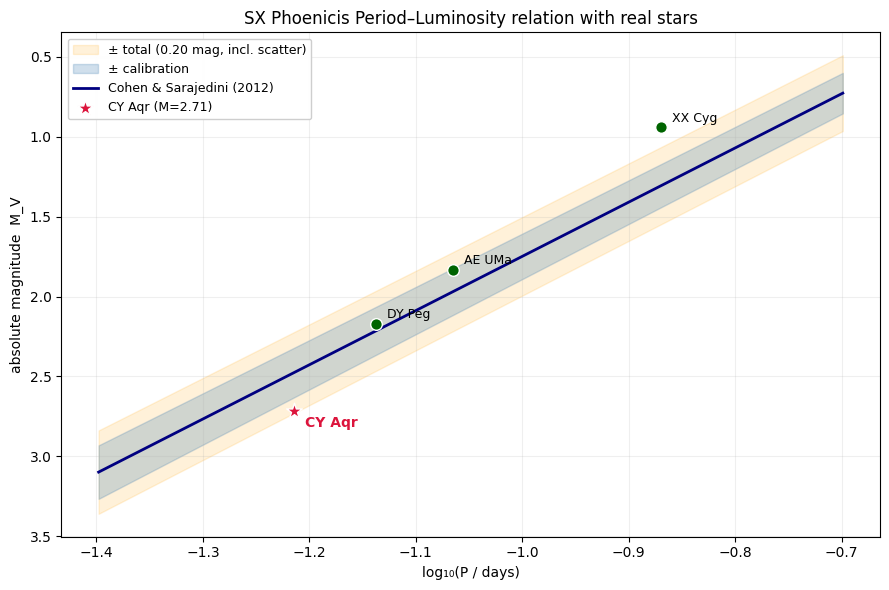


Note: green stars use approximate mid-range V (illustrative scatter),
CY Aqr uses your measured intensity-mean V. Bands are the C&S relation.


In [14]:
# Cell 9 — PL relation with real SX Phe stars scattered around it
#   The Cohen & Sarajedini line + uncertainty bands, then several real SX Phe
#   stars placed by (period, Gaia distance). CY Aqr highlighted. Other stars'
#   M_V come from an approximate mid-range V + Gaia parallax — ILLUSTRATIVE
#   context (shows real scatter), not a rigorous fit sample.

from astroquery.simbad import Simbad
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u

# --- verified SX Phe stars: name, fundamental period (d), approx mid V ---
#     Periods & V ranges sourced from literature (see chat). mid_V is the
#     midpoint of the published V range — approximate, not an intensity mean.
SXPHE_STARS = [
    # name,        P_fund (d),   mid_V,   note
    ("DY Peg",     0.072926,     10.28),   # V 9.95-10.62  (Wikipedia/IOP)
    ("AE UMa",     0.0860171,    11.19),   # V 10.86-11.52 (MNRAS/Wikipedia)
    ("XX Cyg",     0.1348652,    11.30),   # period ADS; V approx
    # CY Aqr handled separately below (uses YOUR measured V + Gaia)
]

def gaia_dist_by_name(name):
    """Resolve a name via SIMBAD, get Gaia DR3 Bailer-Jones geo distance."""
    res = Simbad.query_object(name)
    ra_col  = "ra"  if "ra"  in res.colnames else "RA"
    dec_col = "dec" if "dec" in res.colnames else "DEC"
    try:
        c = SkyCoord(float(res[ra_col][0])*u.deg, float(res[dec_col][0])*u.deg, frame="icrs")
    except (ValueError, TypeError):
        c = SkyCoord(str(res[ra_col][0]), str(res[dec_col][0]),
                     unit=(u.hourangle, u.deg), frame="icrs")
    adql = f"""
    SELECT bj.r_med_geo
    FROM gaiadr3.gaia_source AS g
    JOIN external.gaiaedr3_distance AS bj ON g.source_id = bj.source_id
    WHERE 1=CONTAINS(POINT('ICRS', g.ra, g.dec),
                     CIRCLE('ICRS', {c.ra.deg}, {c.dec.deg}, {3/3600.0}))
    ORDER BY g.phot_g_mean_mag ASC
    """
    t = Gaia.launch_job(adql).get_results()
    return float(t[0]["r_med_geo"]) if len(t) else None

# --- build the sample: each star's (logP, M_V) from period + Gaia distance ---
def build_star(name, P, V_mid, A_V=0.10):
    d = gaia_dist_by_name(name)
    if d is None:
        print(f"  {name}: no Gaia distance, skipping")
        return None
    M_V_star = V_mid - 5*np.log10(d) + 5 - A_V
    print(f"  {name}: d={d:.0f} pc, V~{V_mid} -> M_V~{M_V_star:.2f}")
    return (np.log10(P), M_V_star)

print("resolving SX Phe stars via Gaia:")
pts = [(n, build_star(n, P, V)) for n, P, V in SXPHE_STARS]
pts = [(n, xy) for n, xy in pts if xy is not None]

# CY Aqr from YOUR data (res_V) + Gaia
d_cy   = gaia["d_bj_geo_pc"]
M_cy   = res_V["mean_mag"] - 5*np.log10(d_cy) + 5 - 0.10
logP_cy = np.log10(P_CYAQR)

# --- the relation + bands ---
logP_grid = np.linspace(np.log10(0.04), np.log10(0.20), 200)
M_line  = A_CS + B_CS * logP_grid
sig_cal = np.sqrt(A_ERR**2 + (logP_grid * B_ERR)**2)
sig_tot = np.sqrt(sig_cal**2 + SIGMA_INTRINSIC**2)

fig, ax = plt.subplots(figsize=(9, 6))
ax.fill_between(logP_grid, M_line - sig_tot, M_line + sig_tot,
                color="orange", alpha=0.15, label=f"± total ({SIGMA_INTRINSIC:.2f} mag, incl. scatter)")
ax.fill_between(logP_grid, M_line - sig_cal, M_line + sig_cal,
                color="steelblue", alpha=0.25, label="± calibration")
ax.plot(logP_grid, M_line, "-", color="navy", lw=2, label="Cohen & Sarajedini (2012)")

# other SX Phe stars
for name, (lp, mv) in pts:
    ax.scatter(lp, mv, s=70, color="darkgreen", zorder=5, edgecolor="white")
    ax.annotate(name, (lp, mv), textcoords="offset points", xytext=(8, 4), fontsize=9)

# CY Aqr highlighted
ax.scatter(logP_cy, M_cy, s=140, color="crimson", marker="*", zorder=6,
           edgecolor="white", label=f"CY Aqr (M={M_cy:.2f})")
ax.annotate("CY Aqr", (logP_cy, M_cy), textcoords="offset points",
            xytext=(8, -12), fontsize=10, color="crimson", weight="bold")

ax.invert_yaxis()
ax.set_xlabel("log₁₀(P / days)")
ax.set_ylabel("absolute magnitude  M_V")
ax.set_title("SX Phoenicis Period–Luminosity relation with real stars")
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("cyaqr_pl_stars.png", dpi=200, bbox_inches="tight")
plt.show()
print("\nNote: green stars use approximate mid-range V (illustrative scatter),")
print("CY Aqr uses your measured intensity-mean V. Bands are the C&S relation.")

In [15]:
# Cell 10 — Pull CY Aqr's AAVSO comparison-star sequence (VSP API)
import requests, numpy as np, pandas as pd

CYAQR_V   = 10.83
CYAQR_BV  = 0.30

# --- tunable search parameters ---
FOV      = 60       # arcmin — widen to find more comps (was 30)
MAGLIMIT = 14.5     # faint limit — deeper pulls in more/fainter comps

url = ("https://www.aavso.org/apps/vsp/api/chart/"
       f"?format=json&star=CY%20Aqr&fov={FOV}&maglimit={MAGLIMIT}")
r = requests.get(url, headers={"User-Agent": "Mozilla/5.0 (photometry project)"},
                 timeout=30)
r.raise_for_status()
chart = r.json()
print(f"chart id: {chart.get('chartid')}   FOV: {chart.get('fov')}'  "
      f"maglimit: {chart.get('maglimit')}  comps: {len(chart.get('photometry', []))}")

rows = []
for star in chart.get("photometry", []):
    bands = {b["band"]: (b["mag"], b.get("error")) for b in star["bands"]}
    if "V" not in bands:
        continue
    V, Verr = bands["V"]
    BV = (bands["B"][0] - V) if "B" in bands else np.nan
    rows.append({"auid": star["auid"], "label": star.get("label"),
                 "ra": star["ra"], "dec": star["dec"],
                 "V": V, "Verr": Verr, "B_V": BV})

comps = pd.DataFrame(rows)
comps["dV"]  = (comps["V"]  - CYAQR_V).abs()
comps["dBV"] = (comps["B_V"] - CYAQR_BV).abs()
comps["score"] = comps["dV"] + 2.0 * comps["dBV"].fillna(0.5)
comps = comps.sort_values("score")

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print("\nBest comparison stars (closest in brightness + color):")
print(comps[["label","auid","ra","dec","V","Verr","B_V","dV","dBV"]].head(10).to_string(index=False))

chart id: X42801YT   FOV: 60.0'  maglimit: 14.5  comps: 12

Best comparison stars (closest in brightness + color):
label        auid          ra        dec      V  Verr   B_V    dV   dBV
  109 000-BLD-972 22:38:50.43 01:49:11.0 10.873 0.065 0.703 0.043 0.403
  104 000-BLD-973 22:36:55.99 01:54:33.3 10.417 0.051 0.671 0.413 0.371
  117 000-BCQ-590 22:38:07.63 01:32:28.6 11.740 0.100 0.477 0.910 0.177
  110 000-BLD-971 22:37:36.33 01:42:38.2 11.019 0.076 0.866 0.189 0.566
  113 000-BLD-974 22:39:04.88 01:15:47.6 11.259 0.006 0.850 0.429 0.550
   97 000-BCQ-596 22:38:35.36 01:11:31.4  9.729 0.042 0.714 1.101 0.414
  129 000-BCQ-610 22:39:01.92 01:14:11.0 12.941 0.010 0.498 2.111 0.198
   89 000-BCQ-597 22:38:36.17 01:08:07.7  8.889 0.034 0.942 1.941 0.642
  138 000-BCQ-605 22:38:43.98 01:12:48.7 13.792 0.022 0.549 2.962 0.249
  140 000-BCQ-584 22:37:44.57 01:37:55.3 13.990 0.100 0.701 3.160 0.401
